Лабораторная работа №1

Выпонил: Ковалев Руслан Бабекович || 466200 || K3242

Численные Методы Моделирования

Подключаем библиотеки:


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm,cond,solve
import time
np.set_printoptions(precision=4)

1. Точные методы решения СЛАУ

1.1 Метод Гаусса с частичным выбором главного элемента

Теория

Метод Гаусса используется для приведения матрицы системы к верхнетреугольному виду. Частичный выбор главного элемнта повышает численную устойчивость метода за счёт перестановки строк.

In [14]:
def gauss_partial_pivot(A, b):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)


    for k in range(n - 1):
        p = np.argmax(np.abs(A[k:, k])) + k
        if p != k:
            A[[k, p]] = A[[p, k]]
            b[[k, p]] = b[[p, k]]
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]


    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]
    return x

Теперь проверим корректность

In [15]:
for n in [10, 50]:
    A = np.random.randn(n, n)
    b = np.random.randn(n)
    x = gauss_partial_pivot(A, b)
    print(f"n={n}, ||Ax-b|| = {norm(A @ x - b):.2e}")

n=10, ||Ax-b|| = 8.11e-15
n=50, ||Ax-b|| = 4.08e-14


1.2 LU-разложение

Теория

LU-разложение представляет матрицу в виде произведения нижней и верхней треугольных матриц: A = LU.

In [16]:
def lu_decomposition(A):
    A = A.astype(float)
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()

    for k in range(n - 1):
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return L, U

def lu_solve(L, U, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]
    return x


# Проверка корректности 
n = 10
A = np.random.randn(n, n)
b = np.random.randn(n)

L, U = lu_decomposition(A)
x = lu_solve(L, U, b)

print("LU: ||Ax - b|| =", norm(A @ x - b))


LU: ||Ax - b|| = 2.631954563432281e-15


1.3 Разложение Холецкого

Теория

Для симметричных положительно определённых матриц существует разложение A = LLᵀ.

In [17]:
def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros_like(A)
    for i in range(n):
        for j in range(i + 1):
            s = sum(L[i, k] * L[j, k] for k in range(j))
            if i == j:
                L[i, j] = np.sqrt(A[i, i] - s)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

# Проверка корректности разложения Холецкого
n = 10
B = np.random.randn(n, n)
A = B.T @ B + n * np.eye(n)   # симметричная положительно определённая матрица
b = np.random.randn(n)

L = cholesky_decomposition(A)

y = np.linalg.solve(L, b)
x = np.linalg.solve(L.T, y)

print("Cholesky: ||Ax - b|| =", norm(A @ x - b))


Cholesky: ||Ax - b|| = 6.4018582627671775e-16




Исследование Устойчивости и Масштабируемости

Устойчивость на матрице Гильберта Hn
n=5, cond(Hn)=4.77e+05
n=7, cond(Hn)=4.75e+08
n=9, cond(Hn)=4.93e+11
n=12, cond(Hn)=1.71e+16


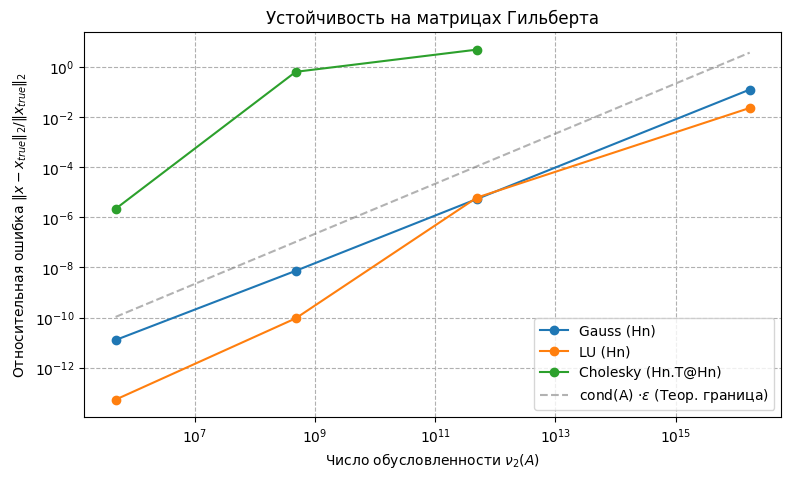


Диагонально преобладающая матрица
Размерность n=10, Число обусловленности cond(A)=1.63e+00 (Хорошо обусловлена)
Ошибка Гаусса: 2.02e-16
Ошибка LU:    2.48e-16

 Исследование масштабируемости по n
n=100: Гаусс=0.0085с, LU=0.0077с, Холецкий=0.0479с
n=300: Гаусс=0.0656с, LU=0.0632с, Холецкий=1.0584с
n=500: Гаусс=0.1909с, LU=0.1860с, Холецкий=4.9367с
n=700: Гаусс=0.4094с, LU=0.3891с, Холецкий=13.4722с


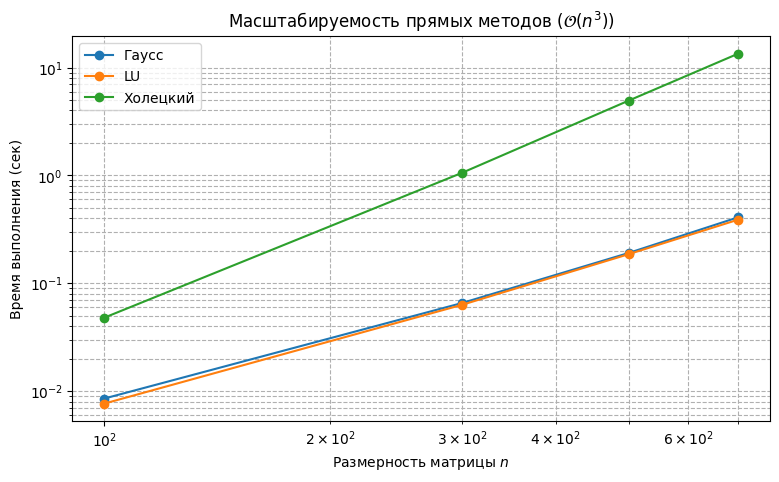

In [18]:
import warnings #  для управления предупреждениями



def hilbert(n):
    #Генерирует матрицу Гильберта Hn = 1/(i + j + 1)
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])

def solve_cholesky(A, b):
    # Решает СЛАУ Ax=b с помощью разложения Холецкого 
    L = cholesky_decomposition(A)
    # 1. Прямая подстановка
    y = np.linalg.solve(L, b)
    # 2. Обратная подстановка
    x = np.linalg.solve(L.T, y)
    return x



print("Устойчивость на матрице Гильберта Hn")
ns_hilbert = [5, 7, 9, 12]
results_hilbert = {
    'Gauss (Hn)': [], 'LU (Hn)': [], 'Cholesky (Hn.T@Hn)': [],
    'Condition Number': []
}

# Отключаем предупреждения о sqrt, чтобы не засорять вывод, т.к. ошибка ожидаема
warnings.filterwarnings("ignore", category=RuntimeWarning) 

for n in ns_hilbert:
    H = hilbert(n)
    A_SPO = H.T @ H
    x_true = np.ones(n)
    b_H = H @ x_true
    b_SPO = A_SPO @ x_true
    
    condA = cond(H)
    results_hilbert['Condition Number'].append(condA)
    
    try:
        x_gauss = gauss_partial_pivot(H, b_H)
        results_hilbert['Gauss (Hn)'].append(norm(x_gauss - x_true) / norm(x_true))
    except Exception:
        results_hilbert['Gauss (Hn)'].append(np.nan)

    try:
        L_lu, U_lu = lu_decomposition(H)
        x_lu = lu_solve(L_lu, U_lu, b_H)
        results_hilbert['LU (Hn)'].append(norm(x_lu - x_true) / norm(x_true))
    except Exception:
        results_hilbert['LU (Hn)'].append(np.nan)

    try:
        x_chol = solve_cholesky(A_SPO, b_SPO)
        results_hilbert['Cholesky (Hn.T@Hn)'].append(norm(x_chol - x_true) / norm(x_true))
    except (ValueError, np.linalg.LinAlgError):
        results_hilbert['Cholesky (Hn.T@Hn)'].append(np.nan)

    print(f"n={n}, cond(Hn)={condA:.2e}")
#  предупреждения обратно по приколу))
warnings.filterwarnings("default", category=RuntimeWarning) 

# График зависимости ошибки от обусловленности
plt.figure(figsize=(9, 5))
conds_arr = np.array(results_hilbert['Condition Number'])
eps = np.finfo(float).eps

for label, errors in results_hilbert.items():
    if label != 'Condition Number':
        errors_arr = np.array(errors)
        finite_indices = np.isfinite(errors_arr)
        plt.loglog(conds_arr[finite_indices], errors_arr[finite_indices], marker='o', label=label)

plt.loglog(conds_arr, conds_arr * eps, '--', color='gray', alpha=0.6, label=r'cond(A) $\cdot \epsilon$ (Теор. граница)') 
plt.xlabel(r"Число обусловленности $\nu_2(A)$")
plt.ylabel(r"Относительная ошибка $\|x - x_{true}\|_2 / \|x_{true}\|_2$") 
plt.title(r"Устойчивость на матрицах Гильберта") 
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print("\nДиагонально преобладающая матрица")
n_dp = 10
A_rand = np.random.randn(n_dp, n_dp)

# Создание диагонально преобладающей матрицы
D_sum = np.sum(np.abs(A_rand), axis=1) - np.abs(np.diag(A_rand))
A_DP = A_rand + np.diag(D_sum + 10 * np.ones(n_dp)) 

x_true = np.ones(n_dp)
b_DP = A_DP @ x_true
cond_DP = cond(A_DP)

print(f"Размерность n={n_dp}, Число обусловленности cond(A)={cond_DP:.2e} (Хорошо обусловлена)")

# Сравнение ошибок на хорошо обусловленной матрице
try:
    x_gauss = gauss_partial_pivot(A_DP, b_DP)
    print(f"Ошибка Гаусса: {norm(x_gauss - x_true) / norm(x_true):.2e}")
except Exception:
    print("Ошибка Гаусса: сбой")

try:
    x_lu = lu_solve(*lu_decomposition(A_DP), b_DP)
    print(f"Ошибка LU:    {norm(x_lu - x_true) / norm(x_true):.2e}")
except Exception:
    print("Ошибка LU:    сбой")




print("\n Исследование масштабируемости по n")
ns_scale = [100, 300, 500, 700]
alpha = 1.0 
scaling_results = {'Гаусс': [], 'LU': [], 'Холецкий': []}

for n in ns_scale:
    # Генерация СПО-матрицы A = B.T @ B + alpha * I
    B = np.random.randn(n, n)
    A = B.T @ B + alpha * np.eye(n)
    
    x_true = np.ones(n)
    b = A @ x_true
    
    times = {}

    # Измерение времени Гаусса
    t0 = time.time()
    try:
        gauss_partial_pivot(A, b)
        times['Гаусс'] = time.time() - t0
    except:
        times['Гаусс'] = np.nan
    
    # Измерение времени LU
    t0 = time.time()
    try:
        L, U = lu_decomposition(A)
        lu_solve(L, U, b)
        times['LU'] = time.time() - t0
    except:
        times['LU'] = np.nan

    # Измерение времени Холецкого
    t0 = time.time()
    try:
        solve_cholesky(A, b) 
        times['Холецкий'] = time.time() - t0
    except:
        times['Холецкий'] = np.nan
    
    scaling_results['Гаусс'].append(times['Гаусс'])
    scaling_results['LU'].append(times['LU'])
    scaling_results['Холецкий'].append(times['Холецкий'])
    
    print(f"n={n}: Гаусс={times['Гаусс']:.4f}с, LU={times['LU']:.4f}с, Холецкий={times['Холецкий']:.4f}с")


# График масштабируемости
plt.figure(figsize=(9, 5))
for method, times in scaling_results.items():
    plt.loglog(ns_scale, times, marker='o', label=method)

plt.xlabel(r"Размерность матрицы $n$")
plt.ylabel(r"Время выполнения (сек)")
plt.title(r"Масштабируемость прямых методов ($\mathcal{O}(n^3)$)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

2. Итерационные методы решения СЛАУ

2.1 Метод Якоби

In [19]:
def jacobi(A, b, x0, tol=1e-8, max_iter=10000):
    n = len(b)
    x = x0.copy()
    
    # 1. Формируем D (как матрицу) и D_inv (обратную матрицу)
    D_mat = np.diag(np.diag(A))
    # Обратная матрица диагонали D^-1
    D_inv = np.diag(1.0 / np.diag(A))
    
    # 2. Формируем R = L + U (офф-диагональная часть)
    R = A - D_mat 
    
    history = []
    for k in range(max_iter):
        x_new = D_inv @ (b - R @ x) 
        
        history.append(norm(A @ x_new - b))
        if history[-1] < tol:
            break
        x = x_new.copy() 
        
    if history[-1] >= tol:
        print(f"Внимание: Jacobi не сошелся за {max_iter} итераций (остаток {history[-1]:.2e})")
        
    return x, history

2.2 Метод Гаусса–Зейделя

In [20]:
def gauss_seidel(A, b, x0, tol=1e-8, max_iter=10000):
    n = len(b)
    x = x0.copy()
    history = []
    for k in range(max_iter):
        for i in range(n):
            s1 = A[i, :i] @ x[:i]
            s2 = A[i, i + 1:] @ x[i + 1:]
            x[i] = (b[i] - s1 - s2) / A[i, i]
        history.append(norm(A @ x - b))
        if history[-1] < tol:
            break
    return x, history

Сравнение сходимости


Исследование скорости сходимости от размера n
n=100: Jacobi итераций=7, GS итераций=6
n=300: Jacobi итераций=7, GS итераций=6
n=500: Jacobi итераций=6, GS итераций=5


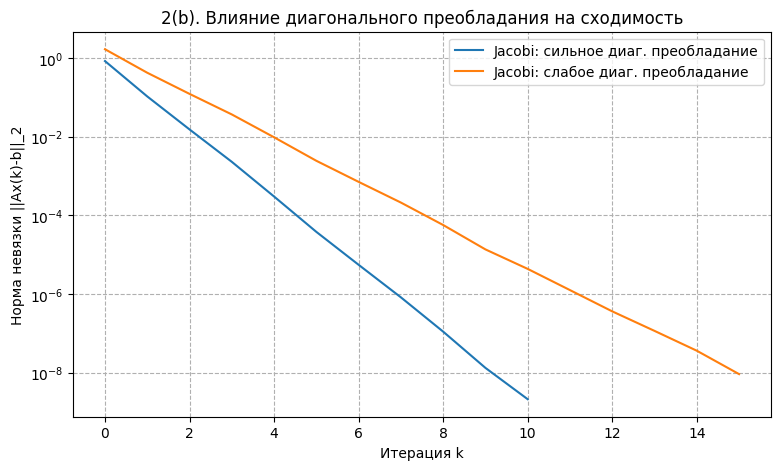

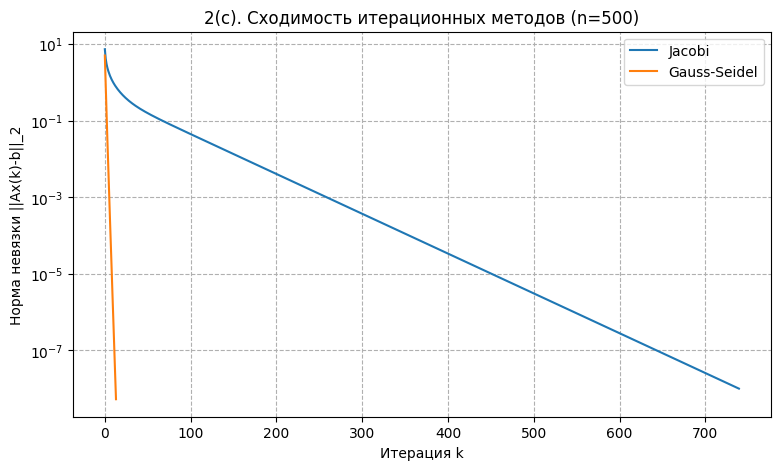


3. Влияние начального приближения x(0)


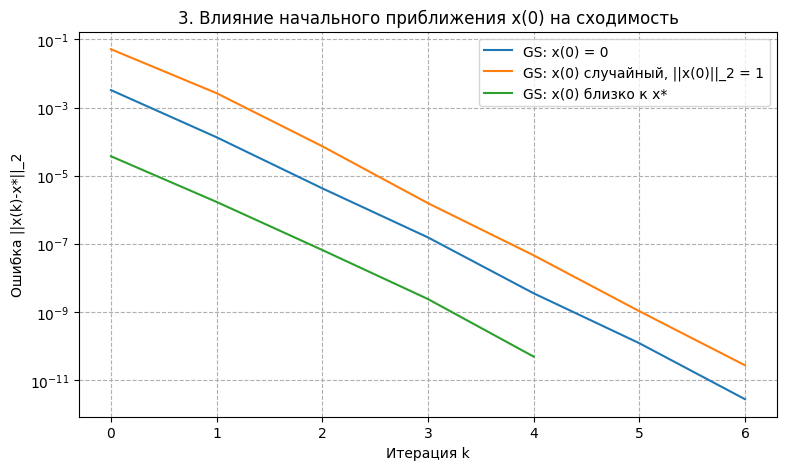

0.9999999999999999


In [25]:


print("\nИсследование скорости сходимости от размера n")

# Сравнение числа итераций от размера n
ns_iter = [100, 300, 500]
iter_results = {'Jacobi': [], 'Gauss-Seidel': []}

for n in ns_iter:
    # Генерация диагонально преобладающей матрицы
    A = np.random.randn(n, n)
    A += 2 * n * np.eye(n) # Обеспечение сильного диагонального преобладания для быстрой сходимости
    b = np.random.randn(n)
    x0 = np.zeros(n)
    
    # Решение
    try:
        _, hist_j = jacobi(A, b, x0)
        iter_results['Jacobi'].append(len(hist_j))
    except Exception:
        iter_results['Jacobi'].append(np.nan)
        
    try:
        _, hist_gs = gauss_seidel(A, b, x0)
        iter_results['Gauss-Seidel'].append(len(hist_gs))
    except Exception:
        iter_results['Gauss-Seidel'].append(np.nan)

    print(f"n={n}: Jacobi итераций={iter_results['Jacobi'][-1]}, GS итераций={iter_results['Gauss-Seidel'][-1]}")

# Изменение матрицы (уменьшение диагональных элементов)
n_mod = 50
A_mod = np.random.randn(n_mod, n_mod)
A_mod += n_mod * np.eye(n_mod) # Изначально диагонально преобладающая
b_mod = np.random.randn(n_mod)
x0_mod = np.zeros(n_mod)

# Уменьшаем диагональные элементы в 2 раза
A_weak = A_mod.copy()
np.fill_diagonal(A_weak, np.diag(A_weak) / 2)

_, hist_strong = jacobi(A_mod, b_mod, x0_mod)
_, hist_weak = jacobi(A_weak, b_mod, x0_mod)

plt.figure(figsize=(9, 5))
plt.semilogy(hist_strong, label='Jacobi: сильное диаг. преобладание')
plt.semilogy(hist_weak, label='Jacobi: слабое диаг. преобладание')
plt.title('2(b). Влияние диагонального преобладания на сходимость')
plt.xlabel('Итерация k')
plt.ylabel('Норма невязки ||Ax(k)-b||_2')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show() 


# График нормы невязки для СПО-матрицы
n_spo = 500
alpha = 2 * n_spo # потестить было alpha = 1.0. Теперь alpha = 1000 для n=500, не забыть ПОТЕСТИТЬ НЕ ЗАБЫТЬ
B = np.random.randn(n_spo, n_spo)

# Генерируем СПО матрицу с сильным диагональным преобладанием
A_spo = B.T @ B + alpha * np.eye(n_spo) 
b_spo = np.random.randn(n_spo)
x0_spo = np.zeros(n_spo)



x_j_spo, hist_j_spo = jacobi(A_spo, b_spo, x0_spo)
x_gs_spo, hist_gs_spo = gauss_seidel(A_spo, b_spo, x0_spo)

plt.figure(figsize=(9, 5))
plt.semilogy(hist_j_spo, label='Jacobi')
plt.semilogy(hist_gs_spo, label='Gauss-Seidel')
plt.title(f'2(c). Сходимость итерационных методов (n={n_spo})')
plt.xlabel('Итерация k')
plt.ylabel('Норма невязки ||Ax(k)-b||_2')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()



#3. ИССЛЕДОВАНИЕ ВЛИЯНИЯ НАЧАЛЬНОГО ПРИБЛИЖЕНИЯ x(0)


print("\n3. Влияние начального приближения x(0)")

n_start = 50
A_start = np.random.randn(n_start, n_start)
A_start += 2 * n_start * np.eye(n_start)
b_start = np.random.randn(n_start)

# Находим точное решение для сравнения
x_true = np.linalg.solve(A_start, b_start)

# Схема для хранения истории ошибки (L2-нормы)
def run_gs_and_track_error(A, b, x0, x_true, tol=1e-8, max_iter=10000):
    n = len(b)
    x = x0.copy()
    L_D = np.tril(A)
    U = A - L_D
    error_history = []
    
    for k in range(max_iter):
        # Использование solve из numpy.linalg
        x_new = solve(L_D, b - U @ x) 
        
        # Запись ошибки: L2-норма разности между текущим и точным решением
        error = norm(x_new - x_true)
        error_history.append(error)
        
        # Критерий останова (по невязке)
        if norm(A @ x_new - b) < tol:
            break
        
        x = x_new
        
    return error_history


# (a) x(0) = 0
x0_a = np.zeros(n_start)
hist_a = run_gs_and_track_error(A_start, b_start, x0_a, x_true)

# (b) x(0) — случайный вектор, ||x(0)||2 = 1
x0_b = np.random.randn(n_start)
x0_b = x0_b / norm(x0_b) # Нормируем
hist_b = run_gs_and_track_error(A_start, b_start, x0_b, x_true)

# (c) x(0) близок к точному решению x*
x0_c = x_true + 1e-4 * np.random.randn(n_start)
hist_c = run_gs_and_track_error(A_start, b_start, x0_c, x_true)

# График зависимости ошибки ||x(k)-x*||2 от k
plt.figure(figsize=(9, 5))
plt.semilogy(hist_a, label='GS: x(0) = 0')
plt.semilogy(hist_b, label='GS: x(0) случайный, ||x(0)||_2 = 1')
plt.semilogy(hist_c, label='GS: x(0) близко к x*')
plt.title('3. Влияние начального приближения x(0) на сходимость')
plt.xlabel('Итерация k')
plt.ylabel('Ошибка ||x(k)-x*||_2')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

3. Нелинейные уравнения (одномерный случай)

3.1 Реализация методов

In [22]:
def newton(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    history = []
    for _ in range(max_iter):
        x = x - f(x) / df(x)
        history.append(abs(f(x)))
        if history[-1] < tol:
            break
    return x, history

def secant(f, x0, x1, tol=1e-10, max_iter=100):
    history = []
    for _ in range(max_iter):
        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        x0, x1 = x1, x2
        history.append(abs(f(x1)))
        if history[-1] < tol:
            break
    return x1, history

def fixed_tangent(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    df0 = df(x0)
    history = []
    for _ in range(max_iter):
        x = x - f(x) / df0
        history.append(abs(f(x)))
        if history[-1] < tol:
            break
    return x, history

3.2 Численные эксперименты

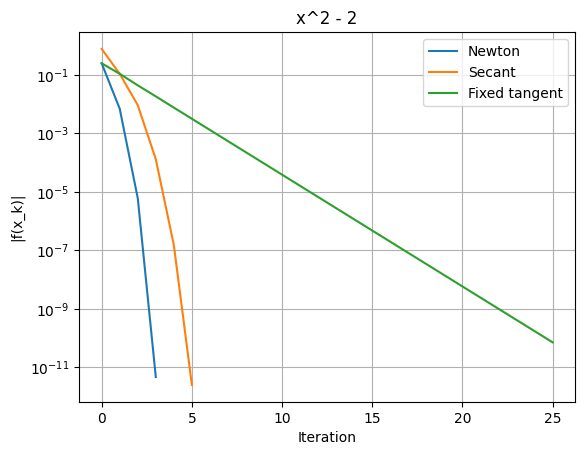

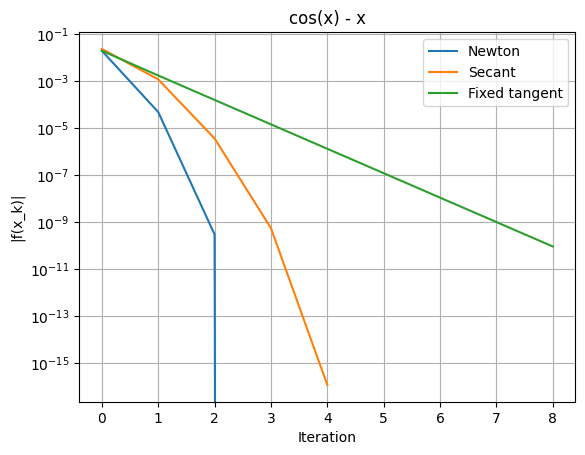

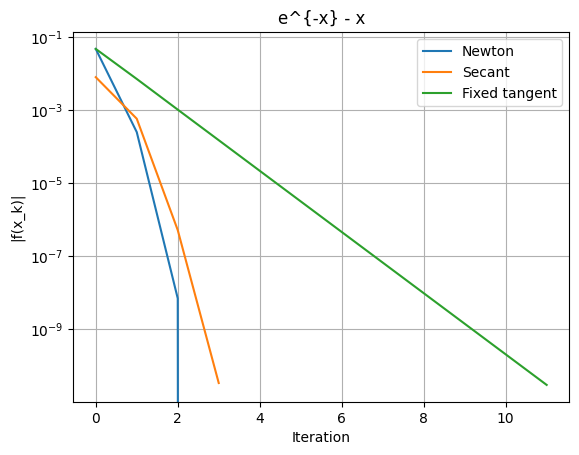

In [23]:
functions = [
    (lambda x: x**2 - 2, lambda x: 2*x, 'x^2 - 2'),
    (lambda x: np.cos(x) - x, lambda x: -np.sin(x) - 1, 'cos(x) - x'),
    (lambda x: np.exp(-x) - x, lambda x: -np.exp(-x) - 1, 'e^{-x} - x')
]


for f, df, name in functions:
    _, h1 = newton(f, df, 1.0)
    _, h2 = secant(f, 0.5, 1.0)
    _, h3 = fixed_tangent(f, df, 1.0)


    plt.semilogy(h1, label='Newton')
    plt.semilogy(h2, label='Secant')
    plt.semilogy(h3, label='Fixed tangent')
    plt.title(name)
    plt.xlabel('Iteration')
    plt.ylabel('|f(x_k)|')
    plt.legend()
    plt.grid()
    plt.show()

/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_27321/3484654344.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - f(x) / df(x)
/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_27321/3484654344.py:5: RuntimeWarning: invalid value encountered in scalar divide
  x = x - f(x) / df(x)
/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_27321/3484654344.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  x = x - f(x) / df0
/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_27321/3484654344.py:26: RuntimeWarning: invalid value encountered in scalar subtract
  x = x - f(x) / df0
/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_27321/139369534.py:8: RuntimeWarning: overflow encountered in scalar power
  (lambda x: x**2 - 2, lambda x: 2*x, 'x^2 - 2', 1.0),


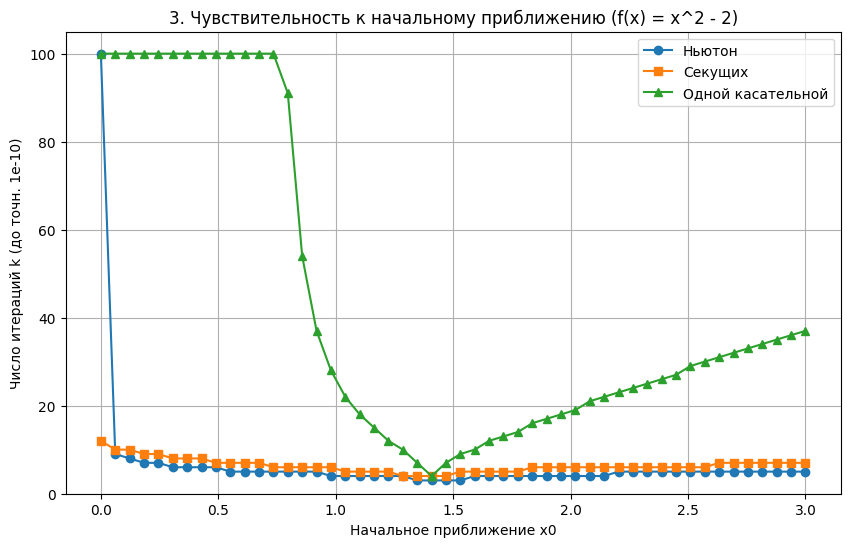

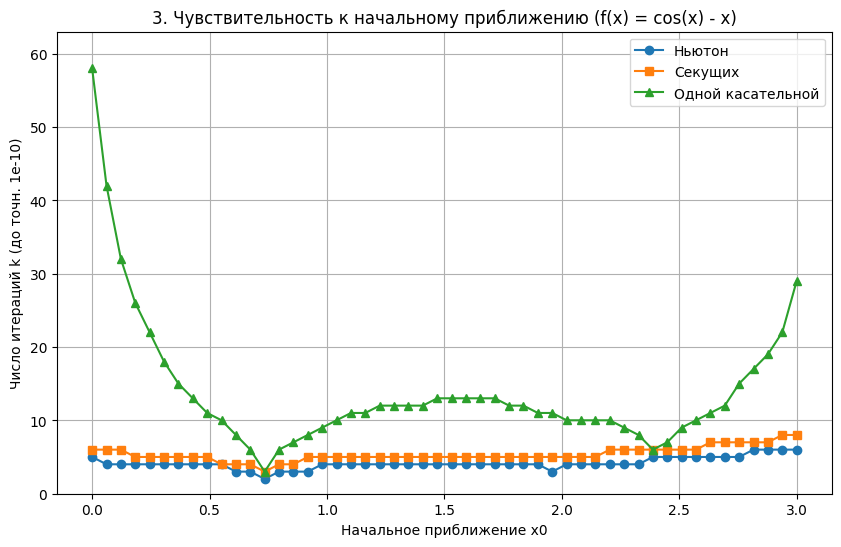

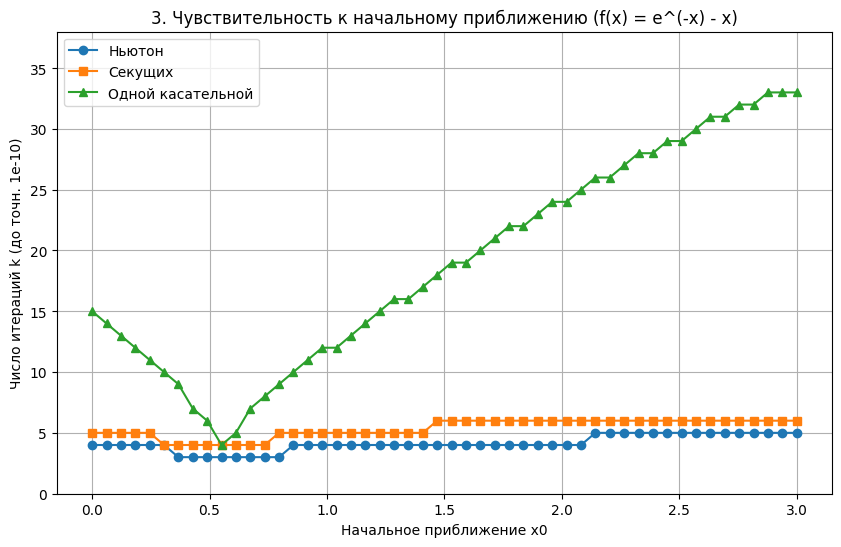

In [24]:
# Точность, требуемая заданием
tol_sens = 1e-10
# Диапазон начальных приближений для тестирования
x0_range = np.linspace(0.0, 3.0, 50) # 50 тестовых точек

functions_sens = [
    # (Функция f, Производная df, Название, Начальное приближение x0 для f1)
    (lambda x: x**2 - 2, lambda x: 2*x, 'x^2 - 2', 1.0),
    (lambda x: np.cos(x) - x, lambda x: -np.sin(x) - 1, 'cos(x) - x', 0.5),
    (lambda x: np.exp(-x) - x, lambda x: -np.exp(-x) - 1, 'e^(-x) - x', 1.0)
]

# Вспомогательная функция для безопасного запуска и подсчета итераций
def safe_run(method, *args, **kwargs):
    #Возвращает число итераций или максимальное значение + 1 при расходимости что бы всё не взрывалось ( это было мучительно )
    try:
        # Извлекаем историю итераций. Число итераций = len(history)
        _, history = method(*args, **kwargs)
        return len(history)
    except Exception:
        # При делении на ноль или не сходимости
        return kwargs.get('max_iter', 100) + 1 

# Запуск экспериментов для каждой функции
for f, df, name, x1_secant_base in functions_sens:
    
    iterations_newton = []
    iterations_secant = []
    iterations_fixed = []
    
    for x0 in x0_range:
        # 1. Метод Ньютона
        k_newton = safe_run(newton, f, df, x0, tol=tol_sens)
        iterations_newton.append(k_newton)

        # 2. Метод Секущих: x1 выбирается как x0 + небольшое смещение
        x1_secant = x0 + 0.1 
        k_secant = safe_run(secant, f, x0, x1_secant, tol=tol_sens)
        iterations_secant.append(k_secant)

        # 3. Метод Одной касательной
        k_fixed = safe_run(fixed_tangent, f, df, x0, tol=tol_sens)
        iterations_fixed.append(k_fixed)

    plt.figure(figsize=(10, 6))
    
    # Максимальное число итераций для оси Y (для лучшей визуализации расходимости)
    max_k = max(max(iterations_newton), max(iterations_secant), max(iterations_fixed))
    
    plt.plot(x0_range, iterations_newton, 'o-', label='Ньютон')
    plt.plot(x0_range, iterations_secant, 's-', label='Секущих')
    plt.plot(x0_range, iterations_fixed, '^-', label='Одной касательной')

    plt.title(f'3. Чувствительность к начальному приближению (f(x) = {name})')
    plt.xlabel('Начальное приближение x0')
    plt.ylabel(f'Число итераций k (до точн. {tol_sens})')
    
    # Установка лимита Y для обрезки экстремальных значений (расходимости)
    # Если метод расходится, точка отображается на max_iter + 1
    plt.ylim(0, max_k + 5) 
    
    plt.legend()
    plt.grid(True)
    plt.show()

Я допускаю, что совершил огромное кол-во ошибок и упущений